# Raw Track Model Comparison

This notebook is the clean raw-count comparison track for the CAST+ conflict modeling redesign.

It freezes the useful baseline structure from `forecast_model/notebooks/model_comparison.ipynb` while narrowing the scope to the agreed first comparison:
- RandomForestRegressor
- LightGBM with Poisson objective
- CatBoostRegressor

Main design choices:
- keep the last-6-month holdout split for comparability
- compare results separately by target
- exclude lagged holiday features from the clean baseline
- keep the feature-family logic explicit rather than relying on one long hidden predictor list

In [17]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

REPO_ROOT = Path(r'C:\Users\Rosa Daneshmandnia\predicting-global-conflict')
if str(REPO_ROOT / 'forecast_model') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'forecast_model'))

RANDOM_STATE = 42


In [18]:
model_data = pd.read_csv(r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\processed\model_data.csv")

model_data = model_data.set_index(['matched_admin1_id', 'month_year'])

model_data = model_data.sort_index()

print(f'Loaded: {model_data.shape[0]:,} rows x {model_data.shape[1]} cols')
model_data.info()
model_data.describe()

Loaded: 278,820 rows x 100 cols
<class 'pandas.DataFrame'>
MultiIndex: 278820 entries, ('ABW - Aruba', '2018-01') to (nan, '2025-06')
Data columns (total 100 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Battles (t-1)                                275633 non-null  float64
 1   Explosions/Remote violence (t-1)             275633 non-null  float64
 2   Protests (t-1)                               275633 non-null  float64
 3   Riots (t-1)                                  275633 non-null  float64
 4   Strategic developments (t-1)                 275633 non-null  float64
 5   Violence against civilians (t-1)             275633 non-null  float64
 6   Excessive force against protesters (t-1)     275633 non-null  float64
 7   Agreement (t-1)                              275633 non-null  float64
 8   Explosions/Remote violence_neighbours (t-1)  275633 non-null  float64
 9   St

,Battles (t-1),Explosions/Remote violence (t-1),Protests (t-1),Riots (t-1),Strategic developments (t-1),Violence against civilians (t-1),Excessive force against protesters (t-1),Agreement (t-1),Explosions/Remote violence_neighbours (t-1),Strategic developments_neighbours (t-1),Protests_neighbours (t-1),Violence against civilians_neighbours (t-1),Battles_neighbours (t-1),Riots_neighbours (t-1),linear_month_trend,year,inflation (t-1),youth_unemployment (t-1),income_inequality (t-1),income_level_code (t-1),christian_holiday_count,islam_holiday_count,shia_holiday_count,hindu_holiday_count,buddhist_holiday_count,jewish_holiday_count,cultural_holiday_count,nonreligious_holiday_count,christian_holiday_count (t-1),islam_holiday_count (t-1),shia_holiday_count (t-1),hindu_holiday_count (t-1),buddhist_holiday_count (t-1),jewish_holiday_count (t-1),cultural_holiday_count (t-1),nonreligious_holiday_count (t-1),majority_pct,minority1_pct,minority2_pct,nonreligpct,weighted_holidays_majority,weighted_holidays_minority1,weighted_holidays_minority2,minority_tension_minority1,minority_tension_minority2,minority_tension_total,total_religious_mobilization,weighted_holidays_majority (t-1),weighted_holidays_minority1 (t-1),weighted_holidays_minority2 (t-1),minority_tension_minority1 (t-1),minority_tension_minority2 (t-1),minority_tension_total (t-1),total_religious_mobilization (t-1),structural_vulnerability,inflation_shock,shock_vulnerability,capacity_adjusted_risk,inflation_change,high_inequality_flag,inflation_shock_poor,conflict_momentum,violence_escalation,macro_conflict_pressure,Battles,Explosions/Remote violence,Violence against civilians,importance_weight,risk_contested_election,risk_crop_failure,risk_economic_concern,risk_ethnic_tension,risk_military_coup,risk_natural_disaster,risk_political_assassination,risk_contested_election (t-1),risk_crop_failure (t-1),risk_economic_concern (t-1),risk_ethnic_tension (t-1),risk_military_coup (t-1),risk_natural_disaster (t-1),risk_political_assassination (t-1)
count,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,278820.000000,278820.000000,189288.000000,123480.000000,94476.000000,192840.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,272970.000000,272970.000000,272970.000000,272970.00000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,78120.000000,278820.000000,78120.000000,77988.000000,186598.000000,278820.000000,278820.000000,275633.000000,275633.000000,78120.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000
mean,1.238741,1.409740,3.471569,0.481844,0.565821,0.856490,0.013707,0.009556,6.946316,2.895836,16.731117,4.464480,6.292723,2.607892,44.500000,2021.266667,7.991595,17.617915,36.342296,0.602489,0.278746,0.098314,0.004810,0.120612,0.004738,0.000721,0.006528,0.787361,0.278947,0.094049,0.004687,0.119989,0.004702,0.000729,0.006603,0.787097,0.669325,0.186145,0.077081,0.07810,0.212077,0.057722,0.027452,0.057722,0.027452,0.085175,0.297252,0.209320,0.057629,0.027432,0.057629,0.027432,0.085061,0.294381,619.152200,0.067614,93.295268,171.944648,0.096593,0.084700,0.026684,12.852434,0.929546,9572.909411,1.236095,1.412173,0.853271,0.225293,0.102593,0.387246,0.250796,0.139022,0.069260,0.350133,0.105297,0.099577,0.380432,0.247174,0.138634,0.068273,0.342364,0.099778
std,13.849694,23.869244,13.955840,5.851017,3.813787,4.079164,0.431490,0.165

In [19]:
RAW_TARGETS = [
    'Battles',
    'Explosions/Remote violence',
    'Violence against civilians',
]

target_summary = pd.DataFrame({
    'mean': model_data[RAW_TARGETS].mean(),
    'std': model_data[RAW_TARGETS].std(),
    'max': model_data[RAW_TARGETS].max(),
    'zero_share': (model_data[RAW_TARGETS] == 0).mean(),
}).round(3)
target_summary

,mean,std,max,zero_share
Battles,1.236,13.938,1664,0.884
Explosions/Remote violence,1.412,23.893,1773,0.943
Violence against civilians,0.853,4.078,234,0.839


## Feature Families

In [20]:
all_cols = model_data.columns.tolist()

raw_targets = RAW_TARGETS.copy()

conflict_lag_features = [
    c for c in all_cols
    if c.endswith('(t-1)') and c.split(' (t-1)')[0] in [
        'Battles',
        'Explosions/Remote violence',
        'Protests',
        'Riots',
        'Strategic developments',
        'Violence against civilians',
        'Excessive force against protesters',
        'Agreement',
    ]
]

neighbor_features = [c for c in all_cols if '_neighbours (t-1)' in c]

time_features = [
    c for c in all_cols
    if c == 'linear_month_trend'
    or c == 'year'
    or c.startswith('month_')
    or c.startswith('quarter_')
]

worldbank_lag_features = [
    c for c in [
        'inflation (t-1)',
        'youth_unemployment (t-1)',
        'income_inequality (t-1)',
        'income_level_code (t-1)',
    ]
    if c in all_cols
]

religion_features = [
    c for c in [
        'majority_religion',
        'majority_pct',
        'minority1_religion',
        'minority1_pct',
        'minority2_religion',
        'minority2_pct',
        'nonreligpct',
    ]
    if c in all_cols
]

holiday_current_features = [
    c for c in all_cols
    if 'holiday_count' in c and '(t-1)' not in c
]

holiday_interaction_current = [
    c for c in [
        'weighted_holidays_majority',
        'weighted_holidays_minority1',
        'weighted_holidays_minority2',
        'minority_tension_minority1',
        'minority_tension_minority2',
        'minority_tension_total',
        'total_religious_mobilization',
    ]
    if c in all_cols
]

wbd_engineered_features = [
    c for c in [
        'structural_vulnerability',
        'inflation_shock',
        'shock_vulnerability',
        'capacity_adjusted_risk',
        'inflation_change',
        'high_inequality_flag',
        'inflation_shock_poor',
        'conflict_momentum',
        'violence_escalation',
        'macro_conflict_pressure',
    ]
    if c in all_cols
]

risk_features = [c for c in all_cols if c.startswith('risk_')]

excluded_holiday_lags = [
    c for c in all_cols
    if 'holiday_count' in c and '(t-1)' in c
]

excluded_holiday_interaction_lags = [
    c for c in all_cols
    if '(t-1)' in c and any(
        k in c for k in ['weighted_holidays', 'minority_tension', 'mobilization']
    )
]

baseline_feature_cols = list(dict.fromkeys(
    conflict_lag_features
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_features
))

feature_family_sizes = pd.Series({
    'conflict_lag_features': len(conflict_lag_features),
    'neighbor_features': len(neighbor_features),
    'time_features': len(time_features),
    'worldbank_lag_features': len(worldbank_lag_features),
    'religion_features': len(religion_features),
    'holiday_current_features': len(holiday_current_features),
    'holiday_interaction_current': len(holiday_interaction_current),
    'wbd_engineered_features': len(wbd_engineered_features),
    'risk_features': len(risk_features),
    'excluded_holiday_lags': len(excluded_holiday_lags),
    'excluded_holiday_interaction_lags': len(excluded_holiday_interaction_lags),
    'baseline_feature_cols': len(baseline_feature_cols),
})

feature_family_sizes

feature_family_preview = {
    'conflict_lag_features': conflict_lag_features,
    'neighbor_features': neighbor_features,
    'time_features': time_features,
    'worldbank_lag_features': worldbank_lag_features,
    'religion_features': religion_features,
    'holiday_current_features': holiday_current_features,
    'holiday_interaction_current': holiday_interaction_current,
    'wbd_engineered_features': wbd_engineered_features,
    'risk_features': risk_features,
    'excluded_holiday_lags': excluded_holiday_lags,
    'excluded_holiday_interaction_lags': excluded_holiday_interaction_lags,
}

for family_name, cols in feature_family_preview.items():
    print(f"\n{family_name} ({len(cols)}):")
    for col in cols:
        print(f"  - {col}")


conflict_lag_features (8):
  - Battles (t-1)
  - Explosions/Remote violence (t-1)
  - Protests (t-1)
  - Riots (t-1)
  - Strategic developments (t-1)
  - Violence against civilians (t-1)
  - Excessive force against protesters (t-1)
  - Agreement (t-1)

neighbor_features (6):
  - Explosions/Remote violence_neighbours (t-1)
  - Strategic developments_neighbours (t-1)
  - Protests_neighbours (t-1)
  - Violence against civilians_neighbours (t-1)
  - Battles_neighbours (t-1)
  - Riots_neighbours (t-1)

time_features (16):
  - linear_month_trend
  - year
  - month_2
  - month_3
  - month_4
  - month_5
  - month_6
  - month_7
  - month_8
  - month_9
  - month_10
  - month_11
  - month_12
  - quarter_2
  - quarter_3
  - quarter_4

worldbank_lag_features (4):
  - inflation (t-1)
  - youth_unemployment (t-1)
  - income_inequality (t-1)
  - income_level_code (t-1)

religion_features (7):
  - majority_religion
  - majority_pct
  - minority1_religion
  - minority1_pct
  - minority2_religion
  - mi

**Input Policy**

- RandomForest: fill numeric/bool NaNs with 0, encode categoricals
- LightGBM-Poisson: keep NaNs, encode categoricals
- CatBoost: configurable native or encoded categorical handling


In [21]:
def split_region_data(region_data, test_horizon=6):
    train = region_data.iloc[:-test_horizon]
    test = region_data.iloc[-test_horizon:]
    return train, test


def encode_categoricals(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()

        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

        X_train[col] = le.fit_transform(X_train[col])

        known = set(le.classes_)
        X_test[col] = X_test[col].map(
            lambda x: le.transform([x])[0] if x in known else -1
        )

    return X_train, X_test


def prepare_rf_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    num_bool_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    X_train[num_bool_cols] = X_train[num_bool_cols].fillna(0)
    X_test[num_bool_cols] = X_test[num_bool_cols].fillna(0)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def prepare_lgbm_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def prepare_catboost_native_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

    return X_train, X_test, cat_cols


def prepare_catboost_encoded_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


CATBOOST_MODE = "native"  # or "encoded"


def prepare_catboost_inputs(train_df, test_df, feature_cols, mode=CATBOOST_MODE):
    if mode == "native":
        return prepare_catboost_native_inputs(train_df, test_df, feature_cols)
    elif mode == "encoded":
        X_train, X_test = prepare_catboost_encoded_inputs(train_df, test_df, feature_cols)
        return X_train, X_test, None
    else:
        raise ValueError("mode must be 'native' or 'encoded'")


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [22]:
MODELS = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300, #usually use fewer trees, stabalize easier
        random_state=RANDOM_STATE,
    ),
    'LightGBM_Poisson': LGBMRegressor(
        objective='poisson',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
}
MODELS


{'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42),
 'LightGBM_Poisson': LGBMRegressor(learning_rate=0.05, max_depth=4, n_estimators=500,
               objective='poisson', random_state=42, verbose=-1),
 'CatBoost': CatBoostRegressor(depth=4, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)}

In [23]:
all_regions = model_data.index.get_level_values('matched_admin1_id').unique()

VALID_REGIONS = []
skipped_too_short = []
skipped_all_zero = []

for region in all_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        skipped_too_short.append(region)
        continue

    train_data, test_data = split_region_data(region_data)

    if train_data[RAW_TARGETS].sum().sum() == 0 and test_data[RAW_TARGETS].sum().sum() == 0:
        skipped_all_zero.append(region)
        continue

    VALID_REGIONS.append(region)

print(f"Valid regions: {len(VALID_REGIONS)}")
print(f"Skipped (<12 months): {len(skipped_too_short)}")
print(f"Skipped (all-zero train+test across targets): {len(skipped_all_zero)}")

VALID_REGIONS[:10]

Valid regions: 2223
Skipped (<12 months): 0
Skipped (all-zero train+test across targets): 875


['ABW - Aruba',
 'AFG - Badakhshan',
 'AFG - Badghis',
 'AFG - Baghlan',
 'AFG - Balkh',
 'AFG - Bamyan',
 'AFG - Daykundi',
 'AFG - Farah',
 'AFG - Faryab',
 'AFG - Ghazni']

In [26]:
DEBUG_REGIONS = VALID_REGIONS
DEBUG_TARGETS = RAW_TARGETS

results = []
feature_importances = {}

for region in DEBUG_REGIONS:
    region_data = model_data.loc[region].sort_index()

    train_data, test_data = split_region_data(region_data)
    weights = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    X_train_rf, X_test_rf = prepare_rf_inputs(train_data, test_data, baseline_feature_cols)
    X_train_lgbm, X_test_lgbm = prepare_lgbm_inputs(train_data, test_data, baseline_feature_cols)
    X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
        train_data, test_data, baseline_feature_cols
    )

    for target in DEBUG_TARGETS:
        y_train = train_data[target]
        y_test = test_data[target]

        if y_train.nunique() <= 1:
            continue

        model_specs = {
            'RandomForest': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            'LightGBM_Poisson': LGBMRegressor(
                objective='poisson',
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
            'CatBoost': CatBoostRegressor(
                iterations=500,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            ),
        }

        for model_name, model in model_specs.items():
            try:
                if model_name == 'RandomForest':
                    X_tr, X_te = X_train_rf, X_test_rf
                    fit_kwargs = {}
                    if weights is not None:
                        fit_kwargs['sample_weight'] = weights.values

                elif model_name == 'LightGBM_Poisson':
                    X_tr, X_te = X_train_lgbm, X_test_lgbm
                    fit_kwargs = {}
                    if weights is not None:
                        fit_kwargs['sample_weight'] = weights.values

                else:
                    X_tr, X_te = X_train_cb, X_test_cb
                    fit_kwargs = {}
                    if cat_cols_cb is not None:
                        fit_kwargs['cat_features'] = cat_cols_cb
                    if weights is not None:
                        fit_kwargs['sample_weight'] = weights.values

                model.fit(X_tr, y_train, **fit_kwargs)
                y_pred = np.clip(model.predict(X_te), 0, None)

                results.append({
                    'region': region,
                    'target': target,
                    'model': model_name,
                    'mae': mean_absolute_error(y_test, y_pred),
                    'rmse': rmse(y_test, y_pred),
                    'mean_actual': y_test.mean(),
                })

                if hasattr(model, 'feature_importances_'):
                    feature_importances[(model_name, region, target)] = pd.Series(
                        model.feature_importances_,
                        index=baseline_feature_cols,
                    )

            except Exception as exc:
                print(f'ERROR | {model_name} | {region} | {target}: {exc}')

results_df = pd.DataFrame(results)
print(f"Rows collected: {len(results_df)}")
results_df

Rows collected: 13017


,region,target,model,mae,rmse,mean_actual
0,AFG - Badakhshan,Battles,RandomForest,0.946667,1.054121,1.166667
1,AFG - Badakhshan,Battles,LightGBM_Poisson,0.865944,0.953366,1.166667
2,AFG - Badakhshan,Battles,CatBoost,1.729009,2.049960,1.166667
3,AFG - Badakhshan,Explosions/Remote violence,RandomForest,0.485000,0.574867,0.000000
4,AFG - Badakhshan,Explosions/Remote violence,LightGBM_Poisson,0.251582,0.274934,0.000000
...,...,...,...,...,...,...
13012,ZWE - Midlands,Battles,LightGBM_Poisson,0.000113,0.000113,0.000000
13013,ZWE - Midlands,Battles,CatBoost,0.018687,0.044274,0.000000
13014,ZWE - Midlands,Violence against civilians,RandomForest,0.107222,0.181368,0.000000
13015,ZWE - Midlands,Violence against civilians,LightGBM_Poisson,0.007311,0.008952,0.000000


In [27]:
summary = results_df.groupby(['model', 'target'])[['mae', 'rmse']].mean().round(3)
summary

mae   rmse
model            target                                  
CatBoost         Battles                     1.761  2.141
                 Explosions/Remote violence  3.660  4.276
                 Violence against civilians  0.914  1.111
LightGBM_Poisson Battles                     1.638  2.044
                 Explosions/Remote violence  3.111  3.848
                 Violence against civilians  0.871  1.073
RandomForest     Battles                     1.801  2.172
                 Explosions/Remote violence  3.929  4.531
                 Violence against civilians  0.908  1.092

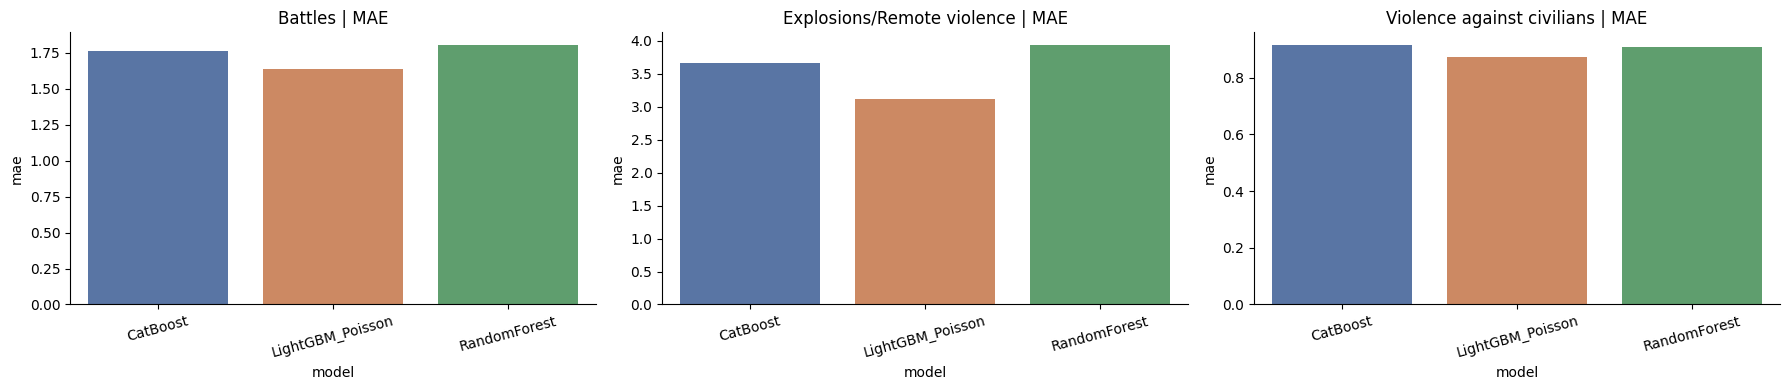

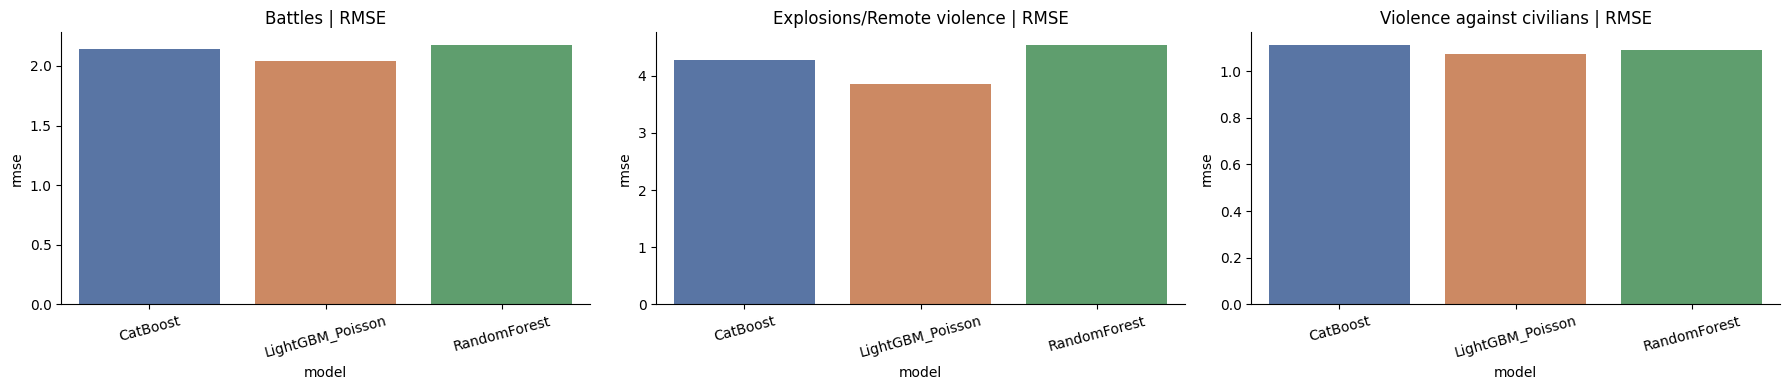

In [28]:
for metric in ['mae', 'rmse']:
    fig, axes = plt.subplots(1, len(RAW_TARGETS), figsize=(6 * len(RAW_TARGETS), 4), sharey=False)
    if len(RAW_TARGETS) == 1:
        axes = [axes]
    for ax, target in zip(axes, RAW_TARGETS):
        subset = results_df[results_df['target'] == target]
        plot_df = subset.groupby('model')[metric].mean().reset_index()
        sns.barplot(data=plot_df, x='model', y=metric, ax=ax, palette='deep')
        ax.set_title(f'{target} | {metric.upper()}')
        ax.tick_params(axis='x', rotation=15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

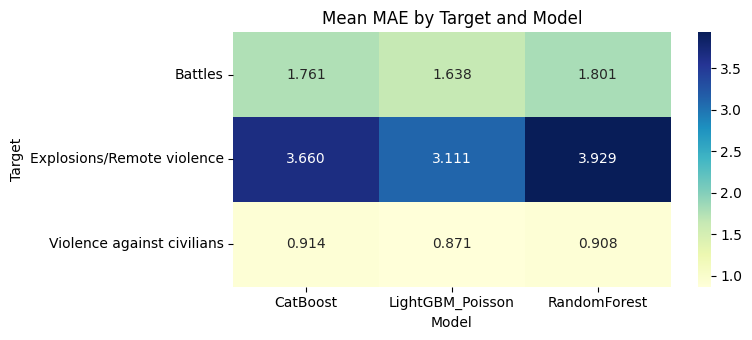

In [29]:
mae_pivot = results_df.pivot_table(
    index='target',
    columns='model',
    values='mae',
    aggfunc='mean'
)

plt.figure(figsize=(8, 3.5))
sns.heatmap(mae_pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Mean MAE by Target and Model')
plt.xlabel('Model')
plt.ylabel('Target')
plt.tight_layout()
plt.show()



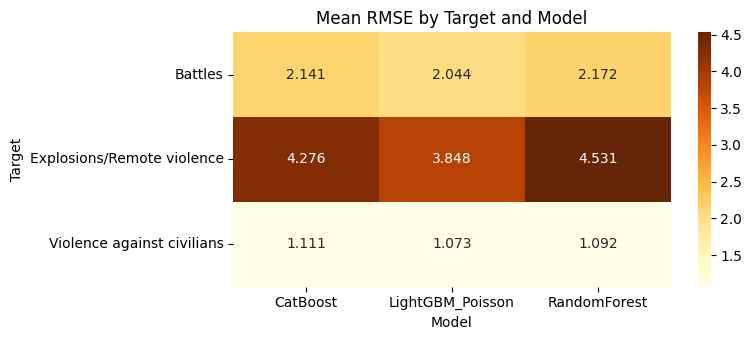

In [30]:
rmse_pivot = results_df.pivot_table(
    index='target',
    columns='model',
    values='rmse',
    aggfunc='mean'
)

plt.figure(figsize=(8, 3.5))
sns.heatmap(rmse_pivot, annot=True, fmt='.3f', cmap='YlOrBr')
plt.title('Mean RMSE by Target and Model')
plt.xlabel('Model')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

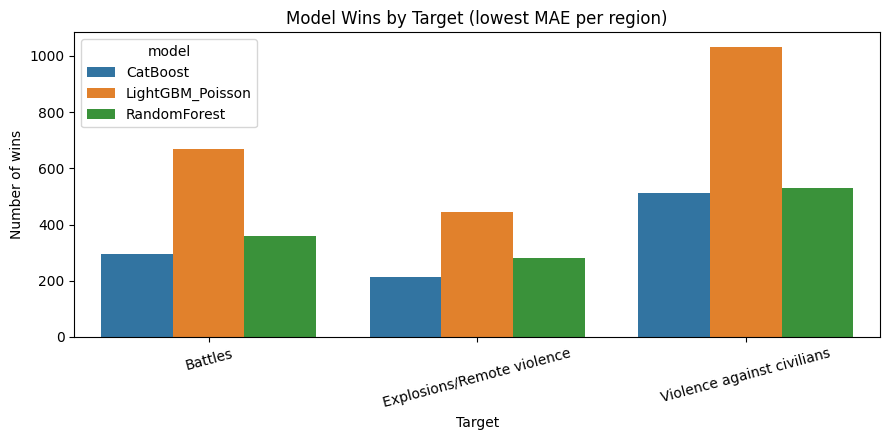

In [31]:
wins_df = (
    results_df.loc[results_df.groupby(['region', 'target'])['mae'].idxmin()]
    .groupby(['target', 'model'])
    .size()
    .reset_index(name='wins')
)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=wins_df, x='target', y='wins', hue='model')
plt.title('Model Wins by Target (lowest MAE per region)')
plt.xlabel('Target')
plt.ylabel('Number of wins')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
